# Machine Learning Model Testing

Notebook 5 tested SARIMAX models and notebook 6 built the features. This notebook tests
**Machine Learning regressors** on the same series (monthly international arrivals to
Brazil, aggregated over all routes, origins and destinations) with the **same protocol as
notebook 5**:

- Every configuration is trained on the training data and forecasts the **validation set**
  (the 12 months before the test year, split in notebook 2).
- Configurations are ranked by **validation RMSE**, and every configuration becomes one MLflow
  run.
- The **test set is never read here**. The final notebook refits the selected configuration
  and evaluates it once on the test year.

The grid crosses six choices:

| Choice | Options |
|---|---|
| **Model family** | Linear Regression, Ridge, Lasso, LightGBM, XGBoost |
| **Target processing** | `none`, `log`, `auto_stationary` (AutoML), as in notebook 5 |
| **Training window** | all history, the last 14 / 12 / 10 / 8 / 6 / 4 years, post-COVID (as in notebook 5) |
| **COVID rows** | `keep` the pandemic years, or `remove` 2020–2022 from the series |
| **Multi-step strategy** | recursive, direct (one model per step), direct with a single model |
| **Feature set** | six combinations of lags, month-over-month growth, rolling statistics, domain flags, calendar and elapsed time |

Choosing the best of thousands of configurations on the same 12 validation months makes the
top validation scores optimistic; that is why the test year is kept apart for an unbiased
final score. The ranking is consistent between notebooks 5 and 7 (same validation year),
which is what the comparison needs.

Global models on the disaggregated series are tested in a separate notebook.

## Setup

In [1]:
import itertools
import json
import logging
import math
import os
import sys
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from typing import NamedTuple

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from dotenv import load_dotenv
from IPython.display import display
from joblib import Parallel, delayed, parallel_config
from lightgbm import LGBMRegressor, early_stopping
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import r2_score
from tqdm import tqdm
from xgboost import XGBRegressor

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-01-01')
COVID_END = pd.Timestamp('2021-12-31')
POST_COVID_START = pd.Timestamp('2022-01-01')
COVID_RECOVERY_END = pd.Timestamp('2022-06-30')

TARGET = 'arrival_count'  # original scale (arrivals)
Y = 'y'  # model scale (after the target processing)
TS_ID = 'series_id'
SERIES_ID = 'brazil_total'
FREQ = 'ME'
SEASONAL_PERIOD = 12
RANDOM_STATE = 42

# physical cores: the fits are small and CPU-bound
N_JOBS = max(1, (os.cpu_count() or 2) // 2)

sns.set_palette('colorblind')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
logging.getLogger('mlflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=FutureWarning)
mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI'))
EXPERIMENT_NAME = 'Brazil Tourism Forecasting ML'
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

### Book Helpers

The training and feature helpers come from the companion repository of:

> Joseph, M. & Tackes, J. *Modern Time Series Forecasting with Python*, 2nd ed.
> (Packt, 2024) — [PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E](https://github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E), MIT License

| Helper | Module | Used for |
|---|---|---|
| `FeatureConfig`, `MissingValueConfig`, `ModelConfig` | `src/forecasting/ml_forecasting.py` | Which columns are features, how to fill gaps, how to scale and encode |
| `MLForecast` | `src/forecasting/ml_forecasting.py` | Wrapper around any scikit-learn regressor: fit, predict, feature importance |
| `calculate_metrics` | `src/forecasting/ml_forecasting.py` | MAE, MSE, MASE and Forecast Bias |
| `add_lags`, `add_rolling_features`, `add_seasonal_rolling_features`, `add_ewma` | `src/feature_engineering/autoregressive_features.py` | Target-derived features |
| `add_temporal_features`, `add_fourier_features` | `src/feature_engineering/temporal_features.py` | Calendar, elapsed time and Fourier terms |
| `AutoStationaryTransformer` | `src/transforms/target_transformations.py` | AutoML target processing (notebook 5) |

Notes on using them here:

- The book's `MLForecast` wraps scikit-learn estimators. It is **not** the `mlforecast`
  library from Nixtla.
- `evaluate_model` in chapter 8 builds `MLForecast` from the **global** `feat_config` and
  `missing_value_config` instead of its own arguments, so every feature set would silently use
  the same features. The version below (`fit_model`) uses its arguments.
- `ModelConfig.categorical_encoder` must expose a `cols` attribute: the `OneHotEncoder` of the
  `category_encoders` package, not scikit-learn's.
- `MLForecast.predict` checks the training columns **before** it applies the categorical
  encoding, so every one-hot model fails at prediction time. The subclass `MLForecastFixed`
  (section 3) runs the same check on the input columns.
- `FeatureConfig.get_X_y` returns its columns in `set` order, which changes from one process to
  the next and makes the tree models' column subsampling irreproducible. `feature_matrix`
  sorts the columns.
- The target processing is applied to the series **before** the features are built, so lags,
  rolling windows and the target share one scale. `MLForecast(target_transformer=...)` would
  only transform `y`.
- Importing `ml_forecasting` pulls in the book's `src.utils`, which imports `torch`,
  `pytorch_lightning`, `humanize` and `datasetsforecast` (< 1.0). They are project dependencies
  for this reason.
- As in notebook 6: `ts_id` is always passed, `add_ewma` gets `spans`, and
  `add_fourier_features` gets `max_value`.

In [2]:
# Helpers credited to: Joseph, M. & Tackes, J. "Modern Time Series Forecasting with
# Python", 2nd ed. (Packt, 2024) — MIT License
# github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E
MTSF_REPO_PATH = os.getenv(
    'MTSF_REPO_PATH',
    os.path.join(
        os.path.dirname(ROOT_PATH), 'Modern-Time-Series-Forecasting-with-Python-2E'
    ),
)
if MTSF_REPO_PATH not in sys.path:
    sys.path.insert(0, MTSF_REPO_PATH)

from src.feature_engineering.autoregressive_features import (  # noqa: E402
    add_ewma,
    add_lags,
    add_rolling_features,
    add_seasonal_rolling_features,
)
from src.feature_engineering.temporal_features import (  # noqa: E402
    add_fourier_features,
    add_temporal_features,
)
from src.forecasting.ml_forecasting import (  # noqa: E402
    FeatureConfig,
    MissingValueConfig,
    MLForecast,
    ModelConfig,
    calculate_metrics,
)
from src.transforms.target_transformations import (  # noqa: E402
    AutoStationaryTransformer,
)

### Target Processing

The same three options as notebook 5. The model learns and predicts on the **transformed**
scale, and every forecast is inverse-transformed to arrivals before scoring.

| Option | Transform | Inverse |
|---|---|---|
| `none` | identity | identity |
| `log` | `log(y)` | `exp(ŷ)` |
| `auto_stationary` | `AutoStationaryTransformer`: detrend / deseasonalize / Box-Cox, each step only when its test asks for it | exact `inverse_transform` of the fitted pipeline |

Why it matters for trees: a tree only predicts values inside the range of its training
targets. On the raw scale, LightGBM and XGBoost cannot forecast arrivals above the historical
maximum.

In [3]:
TARGET_TRANSFORMS = ['none', 'log', 'auto_stationary']


def fit_auto_stationary(train_series):
    """Fit a fresh AutoStationaryTransformer (Mann-Kendall trend, Guerrero Box-Cox)."""
    # fresh dicts every fit: the transformer mutates its parameter dicts in place
    transformer = AutoStationaryTransformer(
        confidence=0.05,
        seasonal_period=SEASONAL_PERIOD,
        trend_check_params={'mann_kendall': True},
        detrender_params={'degree': 1},
        deseasonalizer_params={},
        box_cox_params={'optimization': 'guerrero'},
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return transformer.fit(train_series, freq=FREQ)


class IdentityTarget:
    """No target transformation."""

    @staticmethod
    def transform(y):
        return y

    @staticmethod
    def inverse_transform(y):
        return y


class LogTarget:
    """Natural log of the arrival counts; inverse is exp."""

    @staticmethod
    def transform(y):
        return np.log(y)

    @staticmethod
    def inverse_transform(y):
        return np.exp(y)


def fit_target_transform(name, train_series):
    """Return a fitted transformer exposing `transform` / `inverse_transform`."""
    if name == 'none':
        return IdentityTarget()
    if name == 'log':
        return LogTarget()
    if name == 'auto_stationary':
        return fit_auto_stationary(train_series)
    raise ValueError(f'unknown target transform: {name}')


def describe_transform(name, transformer):
    if name != 'auto_stationary':
        return name
    steps = [
        type(tr).__name__.replace('Transformer', '') for tr in transformer._pipeline
    ]
    return ' → '.join(steps) if steps else '(none)'

## 1. Data, Training Windows and COVID Rows

**Data.** Monthly totals from `train.parquet` and `val.parquet`, the same aggregation as
notebooks 5 and 6. The validation set is the 12 months before the test year, so `HORIZON` and
every date below are read from the files.

**Training windows** (notebook 5, counted back from the last training month). A window selects
the **rows that train the model**; the features still read the whole history, since a row of
2022 needs lags up to 36 months back.

| Window | Training rows |
|---|---|
| `all` | the whole history (from the first month with complete features, 1992) |
| `last_14y` … `last_4y` | the last N years |
| `post_covid` | January 2022 onwards |

**COVID rows.** Two ways to deal with the pandemic:

- `keep`: the series is used as it is. The `domain` group flags the COVID months, the recovery
  months and the lags that point into the pandemic (notebook 6).
- `remove`: the years **2020 to 2022** are cut out of the series **before** the target
  processing, and the features are built on the remaining months. December 2019 is then
  followed by January 2023. Three full years are removed, so the month alignment of every
  seasonal lag is preserved: the `lag_12` of January 2023 is January 2019. The COVID flags no
  longer apply and are replaced by flags that mark the lags **crossing the removed gap**.

`post_covid` has no pandemic rows to remove, so it only runs with `keep`.

Notebook 5 also crossed its windows with two exogenous variants (`covid_exog` and
`covid_recovery_exog`); here both flags are part of the `domain` group.

In [4]:
def load_monthly(file_name):
    raw = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))
    return raw.set_index('date')[TARGET].resample(FREQ).sum()


train_series = load_monthly('train.parquet')
val_series = load_monthly('val.parquet')

HORIZON = len(val_series)
TRAIN_END = train_series.index[-1]
assert val_series.index[0] == TRAIN_END + pd.offsets.MonthEnd(1)

WINDOWS = {
    'all': None,
    **{f'last_{years}y': years for years in [14, 12, 10, 8, 6, 4]},
    'post_covid': POST_COVID_START,
}

REMOVED_START = pd.Timestamp('2020-01-31')
REMOVED_END = pd.Timestamp('2022-12-31')
COVID_ROWS = ['keep', 'remove']


def window_start(window):
    """First training month of a window (counted back from the last training month)."""
    spec = WINDOWS[window]
    if spec is None:
        return train_series.index[0]
    if isinstance(spec, pd.Timestamp):
        return spec
    return TRAIN_END - pd.DateOffset(years=spec)


def training_series(covid_rows):
    if covid_rows == 'remove':
        removed = train_series.index.to_series().between(REMOVED_START, REMOVED_END)
        return train_series[~removed.to_numpy()]
    return train_series


def make_history(transformed, original):
    """History table on the model scale (`y`) with the original target alongside."""
    return pd.DataFrame({
        'date': transformed.index,
        TS_ID: SERIES_ID,
        Y: transformed.to_numpy(),
        TARGET: original.reindex(transformed.index).to_numpy(),
    })


def make_setup(transform_name, covid_rows):
    """Transformer and model-scale history for one target processing and COVID mode."""
    train_part = training_series(covid_rows)
    transformer = fit_target_transform(transform_name, train_part)
    return {
        'transform': transform_name,
        'covid_rows': covid_rows,
        'pipeline': describe_transform(transform_name, transformer),
        'transformer': transformer,
        'train_part': train_part,
        'history': make_history(transformer.transform(train_part), train_part),
    }


setups = {
    (name, covid_rows): make_setup(name, covid_rows)
    for name in TARGET_TRANSFORMS
    for covid_rows in COVID_ROWS
}

print(
    f'Train: {train_series.index[0]:%b %Y} → {TRAIN_END:%b %Y} | '
    f'Validation: {val_series.index[0]:%b %Y} → {val_series.index[-1]:%b %Y} '
    f'(HORIZON = {HORIZON})'
)
display(
    pd.DataFrame([
        {
            'target processing': s['transform'],
            'COVID rows': s['covid_rows'],
            'months': len(s['train_part']),
            'fitted pipeline': s['pipeline'],
        }
        for s in setups.values()
    ])
)
display(
    pd.DataFrame({
        covid_rows: {
            window: len(training_series(covid_rows).loc[window_start(window) :])
            for window in WINDOWS
        }
        for covid_rows in COVID_ROWS
    }).rename_axis('training months per window')
)

Train: Jan 1989 → Aug 2024 | Validation: Sep 2024 → Aug 2025 (HORIZON = 12)


,target processing,COVID rows,months,fitted pipeline
0,none,keep,428,none
1,none,remove,392,none
2,log,keep,428,log
3,log,remove,392,log
4,auto_stationary,keep,428,Detrending → Deseasonalizing → AddM → BoxCox
5,auto_stationary,remove,392,Detrending → Deseasonalizing → AddM → BoxCox


,keep,remove
training months per window,,
all,428,392
last_14y,169,133
last_12y,145,109
last_10y,121,85
last_8y,97,61
last_6y,73,37
last_4y,49,20
post_covid,32,20


## 2. Feature Builder

`build_features(df, shift)` turns notebook 6's pipeline into a function, because the
multi-step strategies need features for different shifts. `shift` is the most recent month the
model may use: the model for step `h` of the **direct** strategy uses `shift = h`, so everything
it sees is known `h` months ahead (chapter 18). The **recursive** model uses `shift = 1`.

| Group | Content |
|---|---|
| `lags` | the two most recent legal lags (`shift`, `shift + 1`) and the seasonal lags 12, 13, 24, 36 that are ≥ `shift` |
| `growth` | **month-over-month growth** of arrivals, `y(t−s) / y(t−s−1) − 1`, at `s = shift` (the latest known change) and `s = 12` (the same change one year earlier, i.e. the expected seasonal move into this month) |
| `rolling` | rolling windows (shifted by `shift`), seasonal rolling windows and EWMA |
| `domain` | `keep`: COVID and recovery flags, COVID flags at each lag, days in month. `remove`: days in month and one flag per lag that crosses the removed gap |
| `cal_cat` | month as a **category** |
| `cal_fourier` | sine / cosine pairs of the month |
| `elapsed` | time elapsed since the epoch |

The growth is computed on the **original** arrivals, so it means the same thing for every
target processing. The recursive strategy therefore converts each fed-back prediction to
arrivals before the next step. The parameters (windows, spans, Fourier terms) are read from
`feature_groups.json` (notebook 6).

In [5]:
with open(os.path.join(DATA_FOLDER_PATH, 'feature_groups.json'), encoding='utf-8') as f:
    FEATURE_SPEC = json.load(f)
PARAMS = FEATURE_SPEC['parameters']
SEASONAL_LAGS = [
    lag
    for lag in FEATURE_SPEC['strategies']['recursive']['lags']
    if lag >= SEASONAL_PERIOD
]

GROUP_ORDER = [
    'lags',
    'growth',
    'rolling',
    'domain',
    'cal_cat',
    'cal_fourier',
    'elapsed',
]
TARGET_DERIVED = ['lags', 'growth', 'rolling']


def lags_for_shift(shift):
    """The two most recent legal lags plus the seasonal lags that are still legal."""
    return sorted({shift, shift + 1} | {lag for lag in SEASONAL_LAGS if lag >= shift})


def growth_lags_for_shift(shift):
    return sorted({shift} | ({SEASONAL_PERIOD} if SEASONAL_PERIOD >= shift else set()))


def is_spliced(df):
    """True when the removed COVID years are missing from the history."""
    return (
        not df['date'].between(REMOVED_START, REMOVED_END).any()
        and (df['date'] > REMOVED_END).any()
    )


def add_domain_features(df, lags):
    df['days_in_month'] = df['date'].dt.days_in_month
    if is_spliced(df):
        # a lag crosses the gap when the row is after it and the lagged row before it
        df['is_pre_gap'] = (df['date'] < REMOVED_START).astype(int)
        df, pre_gap_lags = add_lags(df, lags=lags, column='is_pre_gap', ts_id=TS_ID)
        after_gap = (df['date'] > REMOVED_END).astype(int)
        flags = []
        for lag, column in zip(lags, pre_gap_lags):
            flag = f'crosses_gap_lag_{lag}'
            df[flag] = (df[column].fillna(1) * after_gap).astype(int)
            flags.append(flag)
        return df, ['days_in_month', *flags]
    df['is_covid'] = df['date'].between(COVID_START, COVID_END).astype(int)
    df['is_covid_recovery'] = (
        df['date'].between(POST_COVID_START, COVID_RECOVERY_END).astype(int)
    )
    df, covid_lags = add_lags(df, lags=lags, column='is_covid', ts_id=TS_ID)
    df[covid_lags] = df[covid_lags].fillna(0).astype(int)
    return df, ['is_covid', 'is_covid_recovery', 'days_in_month', *covid_lags]


def build_features(df, shift):
    """Build every feature group for a model that knows the target up to `shift` back.

    `df` has `date`, `series_id`, `y` (model scale) and `arrival_count` (arrivals).
    Future rows have NaN targets. Returns the feature table and {group: [columns]}.
    """
    df = df.copy()
    groups = {}
    lags = lags_for_shift(shift)

    # target-derived groups (book helpers)
    df, groups['lags'] = add_lags(df, lags=lags, column=Y, ts_id=TS_ID)
    df['arrivals_mom_growth'] = df[TARGET] / df[TARGET].shift(1) - 1
    df, groups['growth'] = add_lags(
        df, lags=growth_lags_for_shift(shift), column='arrivals_mom_growth', ts_id=TS_ID
    )
    df, rolling = add_rolling_features(
        df,
        rolls=PARAMS['rolling_windows'],
        column=Y,
        agg_funcs=PARAMS['rolling_aggs'],
        ts_id=TS_ID,
        n_shift=shift,
    )
    df, seasonal = add_seasonal_rolling_features(
        df,
        seasonal_periods=[PARAMS['seasonal_period']],
        rolls=PARAMS['seasonal_windows'],
        column=Y,
        agg_funcs=PARAMS['seasonal_aggs'],
        ts_id=TS_ID,
        n_shift=math.ceil(shift / PARAMS['seasonal_period']),  # counted in seasons
    )
    df, ewma = add_ewma(
        df,
        column=Y,
        alphas=None,
        spans=PARAMS['ewma_spans'],
        ts_id=TS_ID,
        n_shift=shift,
    )
    groups['rolling'] = rolling + seasonal + ewma

    # calendar groups (book helpers); only the month and elapsed time are used
    df, _ = add_temporal_features(
        df,
        field_name='date',
        frequency=FREQ,
        add_elapsed=True,
        prefix='cal',
        drop=False,
    )
    df['cal_Elapsed'] = df['cal_Elapsed'].astype('int64')
    df, groups['cal_fourier'] = add_fourier_features(
        df,
        column_to_encode='cal_Month',
        max_value=12,
        n_fourier_terms=PARAMS['fourier_terms'],
    )
    df['cal_Month'] = pd.Categorical(df['cal_Month'], categories=range(1, 13))
    groups['cal_cat'] = ['cal_Month']
    groups['elapsed'] = ['cal_Elapsed']

    df, groups['domain'] = add_domain_features(df, lags)
    return df, groups


def training_rows(features, groups, start):
    """Rows of the training window with a known target and complete target features.

    The warm-up rows are dropped for every feature set, so all the feature sets of one
    window train on the same months and their scores are comparable.
    """
    target_derived = [c for g in TARGET_DERIVED for c in groups[g]]
    rows = features[features['date'].between(start, TRAIN_END)]
    return rows.dropna(subset=[Y, *target_derived])

In [6]:
MAX_SHOWN = 5
for covid_rows in COVID_ROWS:
    for shift in (1, 12):
        _, example_groups = build_features(setups['none', covid_rows]['history'], shift)
        print(f'COVID rows = {covid_rows}, shift = {shift}')
        display(
            pd.DataFrame({
                'n_columns': {g: len(example_groups[g]) for g in GROUP_ORDER},
                'columns': {
                    g: ', '.join(example_groups[g][:MAX_SHOWN])
                    + (' …' if len(example_groups[g]) > MAX_SHOWN else '')
                    for g in GROUP_ORDER
                },
            })
        )

COVID rows = keep, shift = 1


,n_columns,columns
lags,6,"y_lag_1, y_lag_2, y_lag_12, y_lag_13, y_lag_24 …"
growth,2,"arrivals_mom_growth_lag_1, arrivals_mom_growth..."
rolling,19,"y_rolling_3_mean, y_rolling_3_std, y_rolling_3..."
domain,9,"is_covid, is_covid_recovery, days_in_month, is..."
cal_cat,1,cal_Month
cal_fourier,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."
elapsed,1,cal_Elapsed


COVID rows = keep, shift = 12


,n_columns,columns
lags,4,"y_lag_12, y_lag_13, y_lag_24, y_lag_36"
growth,1,arrivals_mom_growth_lag_12
rolling,19,"y_rolling_3_mean, y_rolling_3_std, y_rolling_3..."
domain,7,"is_covid, is_covid_recovery, days_in_month, is..."
cal_cat,1,cal_Month
cal_fourier,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."
elapsed,1,cal_Elapsed


COVID rows = remove, shift = 1


,n_columns,columns
lags,6,"y_lag_1, y_lag_2, y_lag_12, y_lag_13, y_lag_24 …"
growth,2,"arrivals_mom_growth_lag_1, arrivals_mom_growth..."
rolling,19,"y_rolling_3_mean, y_rolling_3_std, y_rolling_3..."
domain,7,"days_in_month, crosses_gap_lag_1, crosses_gap_..."
cal_cat,1,cal_Month
cal_fourier,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."
elapsed,1,cal_Elapsed


COVID rows = remove, shift = 12


,n_columns,columns
lags,4,"y_lag_12, y_lag_13, y_lag_24, y_lag_36"
growth,1,arrivals_mom_growth_lag_12
rolling,19,"y_rolling_3_mean, y_rolling_3_std, y_rolling_3..."
domain,5,"days_in_month, crosses_gap_lag_12, crosses_gap..."
cal_cat,1,cal_Month
cal_fourier,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."
elapsed,1,cal_Elapsed


### Feature Sets, Feature Config and Missing Values

Six feature sets are tested. They share the core `lags + rolling + domain` and vary the pieces
whose value is an open question: the calendar encoding (category vs Fourier, which chapter 6
says can only be settled empirically), the month-over-month growth, the elapsed time (a
linear model can extrapolate a trend from it; trees cannot), and whether the rolling features
add anything once growth is present.

Each feature set becomes a `FeatureConfig` (book): `cal_Month` is a categorical feature and is
only returned by `get_X_y(..., categorical=True)`; every other group is continuous. The
`MissingValueConfig` back-fills the target-derived columns (the book advises against filling
lags with zero). After the warm-up rows are dropped there are no gaps left in training, so
this only protects against unexpected gaps.

In [7]:
FEATURE_SETS = [
    ('lags', 'rolling', 'domain'),
    ('lags', 'rolling', 'domain', 'cal_cat'),
    ('lags', 'rolling', 'domain', 'cal_fourier'),
    ('lags', 'growth', 'rolling', 'domain', 'cal_fourier'),
    ('lags', 'rolling', 'domain', 'cal_fourier', 'elapsed'),
    ('lags', 'growth', 'domain', 'cal_fourier'),
]


def canonical(feature_set):
    """Order the groups of a feature set consistently."""
    return tuple(g for g in GROUP_ORDER if g in feature_set)


def set_label(feature_set):
    return '+'.join(canonical(feature_set))


def make_feature_config(groups, feature_set):
    continuous = [
        col for g in canonical(feature_set) if g != 'cal_cat' for col in groups[g]
    ]
    categorical = groups['cal_cat'] if 'cal_cat' in feature_set else []
    return FeatureConfig(
        date='date',
        target=Y,
        original_target=TARGET,
        continuous_features=continuous,
        categorical_features=categorical,
        index_cols=['date'],
    )


def make_missing_config(groups):
    return MissingValueConfig(
        bfill_columns=groups['lags'] + groups['growth'] + groups['rolling']
    )

## 3. Model Families

Each family is a `ModelConfig` (book), created fresh for every fit because `MLForecast`
reuses the encoder object stored in the config.

| Family | Estimator | `normalize` | `fill_missing` | Month as category |
|---|---|---|---|---|
| `linear` | `LinearRegression()` | ✓ | ✓ | one-hot |
| `ridge` | `RidgeCV(alphas=10^-3 … 10^3)` | ✓ | ✓ | one-hot |
| `lasso` | `LassoCV(3-fold, 30 alphas)` | ✓ | ✓ | one-hot |
| `lightgbm` | `LGBMRegressor` | ✗ | ✗ (native `NaN`) | native `category` |
| `xgboost` | `XGBRegressor(tree_method='hist')` | ✗ | ✗ (native `NaN`) | native `category` |

- **Linear models.** With `normalize=True` the coefficients are comparable. Ridge (L2)
  shrinks correlated coefficients; Lasso (L1) sets some of them to exactly zero, which works as
  feature selection (chapter 8 uses it for that).
- **Tree models** (chapter 8 recipe, adapted to a short series): a low learning rate (0.02)
  with up to 2,000 trees and **early stopping on the last 12 months of the training window**
  (never on the validation set), then a refit on every training row. About 400 monthly rows is very
  little for the libraries' defaults, so the trees are small (LightGBM `num_leaves=8`,
  XGBoost `max_depth=3`) with row and column subsampling. Windows with fewer than 36 training
  months skip early stopping and use 300 trees. This adaptation is ours, not the book's.
- `n_jobs=1` everywhere, because the configurations already run in parallel.

In [8]:
FAMILIES = ['linear', 'ridge', 'lasso', 'lightgbm', 'xgboost']
FAMILY_NAMES = {
    'linear': 'Linear Regression',
    'ridge': 'Ridge',
    'lasso': 'Lasso',
    'lightgbm': 'LightGBM',
    'xgboost': 'XGBoost',
}
TREE_FAMILIES = {'lightgbm', 'xgboost'}

N_TREES = 2000
LGBM_PARAMS = {
    'n_estimators': N_TREES,
    'learning_rate': 0.02,
    'num_leaves': 8,
    'min_child_samples': 10,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.8,
    'random_state': RANDOM_STATE,
    'n_jobs': 1,
    'verbose': -1,
}
XGB_PARAMS = {
    'n_estimators': N_TREES,
    'learning_rate': 0.02,
    'max_depth': 3,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'enable_categorical': True,
    'random_state': RANDOM_STATE,
    'n_jobs': 1,
}
EARLY_STOPPING_ROUNDS = 100
EARLY_STOPPING_HOLDOUT = 12  # the last 12 months of the training window
MIN_ROWS_FOR_EARLY_STOPPING = 3 * EARLY_STOPPING_HOLDOUT
SHORT_WINDOW_TREES = 300


class MLForecastFixed(MLForecast):
    """Book MLForecast with the predict-time column check done on the *input* columns.

    The book checks the post-encoding training columns before encoding the new rows,
    which fails whenever a categorical feature is one-hot encoded. The rest is the same.
    """

    def fit(self, X, y, is_transformed=False, fit_kwargs=None):
        self._input_features = X.columns.tolist()
        return super().fit(
            X, y, is_transformed=is_transformed, fit_kwargs=fit_kwargs or {}
        )

    def predict(self, X):
        missing = set(self._input_features) - set(X.columns)
        assert not missing, f'features missing at prediction time: {missing}'
        X = X[self._input_features].copy()
        if self.model_config.fill_missing:
            X = self.missing_config.impute_missing_values(X)
        if self.model_config.encode_categorical:
            X = self._cat_encoder.transform(X)
        if self.model_config.normalize:
            scaled = self._continuous_feats + self._encoded_categorical_features
            X[scaled] = self._scaler.transform(X[scaled])
        y_pred = pd.Series(
            self._model.predict(X[self._train_features]).ravel(),
            index=X.index,
            name=f'{self.model_config.name}',
        )
        if self.target_transformer is not None:
            y_pred = self.target_transformer.inverse_transform(y_pred)
        return y_pred


def make_estimator(family):
    if family == 'linear':
        return LinearRegression()
    if family == 'ridge':
        return RidgeCV(alphas=np.logspace(-3, 3, 13))
    if family == 'lasso':
        return LassoCV(alphas=30, cv=3, max_iter=20000)
    if family == 'lightgbm':
        return LGBMRegressor(**LGBM_PARAMS)
    return XGBRegressor(**XGB_PARAMS)


def make_model_config(family, categorical):
    """A fresh ModelConfig (book) for one fit."""
    is_tree = family in TREE_FAMILIES
    encode = categorical and not is_tree
    return ModelConfig(
        model=make_estimator(family),
        name=FAMILY_NAMES[family],
        normalize=not is_tree,
        fill_missing=not is_tree,
        encode_categorical=encode,
        categorical_encoder=OneHotEncoder(cols=['cal_Month']) if encode else None,
    )


def feature_matrix(feature_config, rows, feature_set):
    """`get_X_y` (book) with the columns in a fixed, sorted order."""
    X, y, _ = feature_config.get_X_y(rows, categorical='cal_cat' in feature_set)
    return X[sorted(X.columns)], y


def best_n_estimators(  # noqa: PLR0913, PLR0917
    family, feature_config, missing_config, X, y, categorical
):
    """Early stopping on the last training months (never on the validation set)."""
    probe_config = make_model_config(family, categorical)
    holdout = EARLY_STOPPING_HOLDOUT
    eval_set = [(X.iloc[-holdout:], y.iloc[-holdout:])]
    if family == 'lightgbm':
        fit_kwargs = {
            'eval_set': eval_set,
            'callbacks': [early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
        }
    else:
        probe_config.model.set_params(early_stopping_rounds=EARLY_STOPPING_ROUNDS)
        fit_kwargs = {'eval_set': eval_set, 'verbose': False}
    probe = MLForecastFixed(
        model_config=probe_config,
        feature_config=feature_config,
        missing_config=missing_config,
    )
    probe.fit(X.iloc[:-holdout], y.iloc[:-holdout], fit_kwargs=fit_kwargs)
    if family == 'lightgbm':
        return probe._model.best_iteration_ or N_TREES
    return probe._model.best_iteration + 1


def fit_model(family, feature_set, feature_config, missing_config, train):
    """Chapter 8's `evaluate_model`, split into fit and predict for multi-step use.

    Bug fix kept from the book's version: MLForecast is built from the *arguments*
    (`feature_config`, `missing_config`), not from global variables.
    """
    categorical = 'cal_cat' in feature_set
    X, y = feature_matrix(feature_config, train, feature_set)
    y = y[Y]
    model_config = make_model_config(family, categorical)
    if family in TREE_FAMILIES:
        n_trees = (
            best_n_estimators(family, feature_config, missing_config, X, y, categorical)
            if len(X) >= MIN_ROWS_FOR_EARLY_STOPPING
            else SHORT_WINDOW_TREES
        )
        model_config.model.set_params(n_estimators=n_trees)
    model = MLForecastFixed(
        model_config=model_config,
        feature_config=feature_config,
        missing_config=missing_config,
    )
    model.fit(X, y)
    return model


def predict_rows(model, feature_config, rows, feature_set):
    X, _ = feature_matrix(feature_config, rows, feature_set)
    return model.predict(X)

## 4. Multi-step Strategies

A regressor predicts one value per row. Chapter 18 describes how to turn it into a 12-month
forecast:

| Strategy | Models | How the 12 months are produced | Trade-off |
|---|---|---|---|
| **recursive** | 1 (`shift = 1`) | Predict `T+1`, append it to the history (also converted to arrivals, for the growth features), **rebuild the features with the book helpers**, predict `T+2`, … 12 times | Uses the most recent information, but errors are fed back and can accumulate along the horizon |
| **direct** | 12 (`shift = h` for step `h`) | Model `h` is trained to predict `h` months ahead and forecasts only `T+h` | No error feedback, but 12 models, and the later steps lose the recent lags |
| **direct_single** | 1 (`shift = 12`) | One model whose features are all known 12 months ahead predicts the whole year in one pass | Cheapest, but even step 1 ignores the last 11 months |

A configuration is a `Config` tuple (family, target processing, window, COVID rows, strategy,
feature set).

In [9]:
STRATEGIES = ['recursive', 'direct', 'direct_single']


class Config(NamedTuple):
    family: str
    transform: str
    window: str
    covid_rows: str
    strategy: str
    feature_set: tuple

    @property
    def label(self):
        return (
            f'{FAMILY_NAMES[self.family]} | {self.transform} | {self.window} | '
            f'{self.covid_rows} | {self.strategy} | {set_label(self.feature_set)}'
        )


def to_arrivals(setup, predicted_z):
    """Inverse-transform model-scale predictions (date-indexed Series) to arrivals."""
    return pd.Series(
        np.asarray(setup['transformer'].inverse_transform(predicted_z), dtype=float),
        index=predicted_z.index,
    )


def with_future_rows(history, dates):
    future = pd.DataFrame({'date': dates, TS_ID: SERIES_ID, Y: np.nan, TARGET: np.nan})
    return pd.concat([history, future], ignore_index=True)


def fit_for_shift(config, frame, shift):
    features, groups = build_features(frame, shift)
    feature_config = make_feature_config(groups, config.feature_set)
    model = fit_model(
        config.family,
        config.feature_set,
        feature_config,
        make_missing_config(groups),
        training_rows(features, groups, window_start(config.window)),
    )
    return model, feature_config, features


def forecast_recursive(config, setup, future_dates):
    model, feature_config, _ = fit_for_shift(config, setup['history'], 1)
    extended = setup['history'].copy()
    predictions = []
    for date in future_dates:
        extended = with_future_rows(extended, [date])
        features, _ = build_features(extended, 1)
        row = features.iloc[[-1]]
        pred = predict_rows(model, feature_config, row, config.feature_set).iloc[0]
        last = extended.index[-1]
        extended.loc[last, Y] = pred  # feed the prediction back
        extended.loc[last, TARGET] = to_arrivals(
            setup, pd.Series([pred], index=[date])
        ).iloc[0]
        predictions.append(pred)
    return pd.Series(predictions, index=future_dates), {1: (model, feature_config)}


def forecast_direct(config, setup, future_dates):
    extended = with_future_rows(setup['history'], future_dates)
    predictions, models = [], {}
    for h, date in enumerate(future_dates, start=1):
        model, feature_config, features = fit_for_shift(config, extended, h)
        row = features[features['date'] == date]
        predictions.append(
            predict_rows(model, feature_config, row, config.feature_set).iloc[0]
        )
        models[h] = (model, feature_config)
    return pd.Series(predictions, index=future_dates), models


def forecast_direct_single(config, setup, future_dates):
    shift = len(future_dates)
    extended = with_future_rows(setup['history'], future_dates)
    model, feature_config, features = fit_for_shift(config, extended, shift)
    rows = features[features['date'].isin(future_dates)]
    predictions = predict_rows(model, feature_config, rows, config.feature_set)
    return pd.Series(predictions.to_numpy(), index=future_dates), {
        shift: (model, feature_config)
    }


FORECASTERS = {
    'recursive': forecast_recursive,
    'direct': forecast_direct,
    'direct_single': forecast_direct_single,
}

### Scoring One Configuration

`evaluate_config` is the multi-step counterpart of chapter 8's `evaluate_model`:

1. Forecast the 12 validation months on the model scale with the chosen strategy.
2. Inverse-transform to arrivals.
3. Score against the validation set: the metrics of notebook 5 (**RMSE**, MAE, MAPE, R²), plus the
   book's `calculate_metrics` (MASE and Forecast Bias). MASE uses the full original training
   series as its scale, so it is comparable across windows and COVID options. Forecast Bias
   follows the book: `(Σy − Σŷ) / Σy × 100`, positive = under-forecast.

It runs in parallel worker processes, so it catches its own errors and never calls MLflow.

In [10]:
METRICS = ['RMSE', 'MAE', 'MAPE', 'R2', 'MASE', 'Forecast Bias']


def score(actual, predicted, name):
    metrics = calculate_metrics(actual, predicted, name, train_series)
    errors = (actual - predicted).to_numpy()
    return {
        'RMSE': float(np.sqrt(metrics['MSE'])),
        'MAE': metrics['MAE'],
        'MAPE': float(np.mean(np.abs(errors / actual.to_numpy())) * 100),
        'R2': float(r2_score(actual.to_numpy(), predicted.to_numpy())),
        'MASE': metrics['MASE'],
        'Forecast Bias': metrics['Forecast Bias'],
        'abs_errors': np.abs(errors),
    }


def forecast_arrivals(config, setup):
    predicted_z, models = FORECASTERS[config.strategy](config, setup, val_series.index)
    predicted = to_arrivals(setup, predicted_z)
    if not np.all(np.isfinite(predicted)):
        raise ValueError('non-finite forecast after the inverse transform')
    return predicted, models


def evaluate_config(config, setup):
    """Fit, forecast and score one configuration on the validation set (worker)."""
    result = {**config._asdict(), 'feature_set': set_label(config.feature_set)}
    start = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        try:
            predicted, _ = forecast_arrivals(config, setup)
            result.update(score(val_series, predicted, config.family))
            result.update({'prediction': predicted.to_numpy(), 'error': None})
        except Exception as exc:  # noqa: BLE001 — reported in the results table
            result.update({
                'RMSE': np.inf,
                'error': f'{type(exc).__name__}: {exc}'[:250],
            })
    result['fit_seconds'] = time.perf_counter() - start
    return result


example_config = Config(
    'ridge', 'log', 'last_10y', 'keep', 'recursive', FEATURE_SETS[3]
)
example = evaluate_config(example_config, setups['log', 'keep'])
print(example_config.label)
pd.DataFrame({'actual': val_series, 'forecast': example['prediction']}).assign(
    abs_error=lambda d: (d['actual'] - d['forecast']).abs()
).round(0)

Ridge | log | last_10y | keep | recursive | lags+growth+rolling+domain+cal_fourier


,actual,forecast,abs_error
date,,,
2024-09-30,445389.0,418598.0,26791.0
2024-10-31,508738.0,587272.0,78534.0
2024-11-30,560732.0,630575.0,69843.0
2024-12-31,806478.0,763729.0,42749.0
2025-01-31,1483669.0,1059298.0,424371.0
2025-02-28,1326884.0,833325.0,493559.0
2025-03-31,929096.0,594974.0,334122.0
2025-04-30,686239.0,311896.0,374343.0
2025-05-31,461341.0,232903.0,228438.0


## 5. Baselines

The references of chapter 8, on the same validation set (also computed in notebook 5):

- **naive**: every validation month repeats the last training month.
- **seasonal naive**: every validation month repeats the same month one year earlier.

A model that does not beat the seasonal naive has not learned anything useful from the
features.

In [11]:
baseline_forecasts = {
    'naive': pd.Series(train_series.iloc[-1], index=val_series.index),
    'seasonal_naive': pd.Series(
        train_series.reindex(val_series.index - pd.offsets.MonthEnd(12)).to_numpy(),
        index=val_series.index,
    ),
}
baselines = pd.DataFrame({
    name: score(val_series, predicted, name)
    for name, predicted in baseline_forecasts.items()
}).T
display(baselines[METRICS].astype(float).round(3))
BASELINE_RMSE = float(baselines.loc['seasonal_naive', 'RMSE'])

,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
naive,460440.495,319530.000,33.968,-0.929,3.857,43.328
seasonal_naive,255353.116,209126.083,26.478,0.407,2.525,28.357


## 6. Grid Search

Every combination of the six choices is evaluated (the `post_covid` window only with
`keep`), the same full-grid approach as notebook 5.

**Execution** (as in notebook 5):

1. **Fit in parallel.** Each configuration is fitted and scored in a separate process with
   `joblib` (`N_JOBS` workers, one BLAS thread each). Workers never touch MLflow; every task
   catches its own errors and returns them as a failed result.
2. **Log from the main process.** Every result becomes one MLflow run (params + metrics in a
   single `log_batch` call), logged from `N_LOG_THREADS` threads because the cost is the HTTP
   round-trips. Failed configurations are logged with status `FAILED` and an `error` param.

The direct strategy fits 12 models per configuration and the tree models run early stopping,
so the grid takes a while (roughly 15–25 minutes on 8 cores, plus the MLflow logging).

In [12]:
configs = [
    Config(*choices)
    for choices in itertools.product(
        FAMILIES, TARGET_TRANSFORMS, WINDOWS, COVID_ROWS, STRATEGIES, FEATURE_SETS
    )
    # post_covid has no pandemic rows to remove
    if not (choices[2] == 'post_covid' and choices[3] == 'remove')
]
print(f'Fitting {len(configs)} configurations on {N_JOBS} workers...')

grid_start = time.perf_counter()
with parallel_config(backend='loky', inner_max_num_threads=1):
    results = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(evaluate_config)(config, setups[config.transform, config.covid_rows])
        for config in configs
    )
print(f'Fitting done in {time.perf_counter() - grid_start:,.0f}s')

results_df = pd.DataFrame(results)
failed = results_df[results_df['error'].notna()]
print(f'Failed: {len(failed)} / {len(results_df)}')
if len(failed):
    display(failed['error'].str.split(':').str[0].value_counts().rename('failures'))

Fitting 4050 configurations on 8 workers...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:   16.7s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:   20.5s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:   26.5s
[Parallel(n_jobs=8)]: Done 272 tasks      | elapsed:   34.4s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:   44.1s
[Parallel(n_jobs=8)]: Done 632 tasks      | elapsed:   57.0s
[Parallel(n_jobs=8)]: Done 866 tasks      | elapsed:  1.2min
[Parallel(n_jobs=8)]: Done 1136 tasks      | elapsed:  1.5min
[Parallel(n_jobs=8)]: Done 1442 tasks      | elapsed:  1.8min
[Parallel(n_jobs=8)]: Done 1784 tasks      | elapsed:  2.2min
[Parallel(n_jobs=8)]: Done 2162 tasks      | elapsed:  2.8min
[Parallel(n_jobs=8)]: Done 2576 tasks      | elapsed:  3.6min
[Parallel(n_jobs=8)]: Done 3026 tasks      | elapsed:  4.3min
[Parallel(n_jobs=8)]: Done 3512 tasks      | elapsed: 10.1min
[Parallel(n_jobs=8)]: Done 4034 tasks      | elapsed: 16.5min


Fitting done in 992s
Failed: 61 / 4050


[Parallel(n_jobs=8)]: Done 4050 out of 4050 | elapsed: 16.5min finished


error
ValueError    61
Name: failures, dtype: int64

## 7. Log the Grid to MLflow

One MLflow run per configuration in the experiment **Brazil Tourism Forecasting ML**, with the
six choices as parameters and the validation metrics (`eval_split = validation`). The tracking server runs in Docker
(`docker compose up -d mlflow`).

In [13]:
N_LOG_THREADS = 8
PARAM_KEYS = ['family', 'transform', 'window', 'covid_rows', 'strategy', 'feature_set']
pipelines = {key: setup['pipeline'] for key, setup in setups.items()}


def log_result(client, result):
    params = {
        **{k: result[k] for k in PARAM_KEYS},
        'ast_pipeline': pipelines[result['transform'], result['covid_rows']],
        'horizon': HORIZON,
        'train_end': f'{TRAIN_END:%Y-%m}',
        'eval_split': 'validation',
    }
    if result['error']:
        params['error'] = result['error']
    timestamp = int(time.time() * 1000)
    metrics = [
        mlflow.entities.Metric(key.replace(' ', '_'), float(result[key]), timestamp, 0)
        for key in [*METRICS, 'fit_seconds']
        if key in result and np.isfinite(result[key])
    ]
    run = client.create_run(
        experiment.experiment_id,
        run_name=' | '.join(str(result[k]) for k in PARAM_KEYS),
    )
    client.log_batch(
        run.info.run_id,
        metrics=metrics,
        params=[mlflow.entities.Param(k, str(v)) for k, v in params.items()],
    )
    client.set_terminated(
        run.info.run_id, status='FAILED' if result['error'] else 'FINISHED'
    )


client = mlflow.MlflowClient()
log_start = time.perf_counter()
with ThreadPoolExecutor(max_workers=N_LOG_THREADS) as pool:
    list(
        tqdm(
            pool.map(lambda r: log_result(client, r), results),
            total=len(results),
            desc='Logging to MLflow',
        )
    )
print(f'Logging done in {time.perf_counter() - log_start:,.0f}s')

Logging to MLflow: 100%|██████████| 4050/4050 [10:14<00:00,  6.59it/s]

Logging done in 614s


## 8. Results

All configurations that produced a forecast, ranked by validation RMSE (as in notebook 5). The
seasonal naive is the bar to beat.

In [14]:
ranked = (
    results_df[results_df['error'].isna()].sort_values('RMSE').reset_index(drop=True)
)
ranked['beats_seasonal_naive'] = ranked['RMSE'] < BASELINE_RMSE
print(
    f'{len(ranked)} configurations ranked; '
    f'{ranked["beats_seasonal_naive"].sum()} beat the seasonal naive '
    f'(RMSE {BASELINE_RMSE:,.0f})'
)
ranked[[*PARAM_KEYS, *METRICS, 'fit_seconds']].head(15).round(3)

3989 configurations ranked; 1145 beat the seasonal naive (RMSE 255,353)


,family,transform,window,covid_rows,strategy,feature_set,RMSE,MAE,MAPE,R2,MASE,Forecast Bias,fit_seconds
0,linear,none,last_6y,keep,direct_single,lags+rolling+domain+cal_fourier+elapsed,64292.570,59769.485,9.543,0.962,0.722,1.341,0.065
1,linear,none,last_6y,keep,direct_single,lags+rolling+domain+cal_fourier,64869.784,60318.044,9.605,0.962,0.728,2.069,0.067
2,linear,none,last_6y,keep,direct_single,lags+growth+rolling+domain+cal_fourier,64896.460,60404.475,9.610,0.962,0.729,2.016,0.068
3,linear,none,last_6y,keep,direct_single,lags+rolling+domain,85422.912,69894.660,10.802,0.934,0.844,-0.655,0.062
4,linear,none,last_6y,keep,direct_single,lags+rolling+domain+cal_cat,86458.930,66378.269,9.297,0.932,0.801,6.708,0.106
5,ridge,none,last_6y,keep,direct_single,lags+growth+rolling+domain+cal_fourier,88673.378,73725.662,10.820,0.928,0.890,9.534,0.063
6,ridge,none,last_6y,keep,direct_single,lags+rolling+domain+cal_fourier,88708.875,73807.837,10.833,0.928,0.891,9.503,0.064
7,ridge,none,last_6y,keep,direct_single,lags+rolling+domain,97540.937,83291.921,11.960,0.913,1.006,10.434,0.065
8,linear,auto_stationary,last_6y,keep,direct_single,lags+rolling+domain+cal_fourier,131483.406,116756.260,17.400,0.843,1.409,7.948,0.076
9,linear,auto_stationary,last_6y,keep,direct_single,lags+rolling+domain+cal_cat,131772.483,112288.200,15.854,0.842,1.356,9.672,0.112


### Best Configuration per Family

The best configuration of each family on the validation set, with the same six metrics as
notebook 5. The dashed line is the seasonal naive.

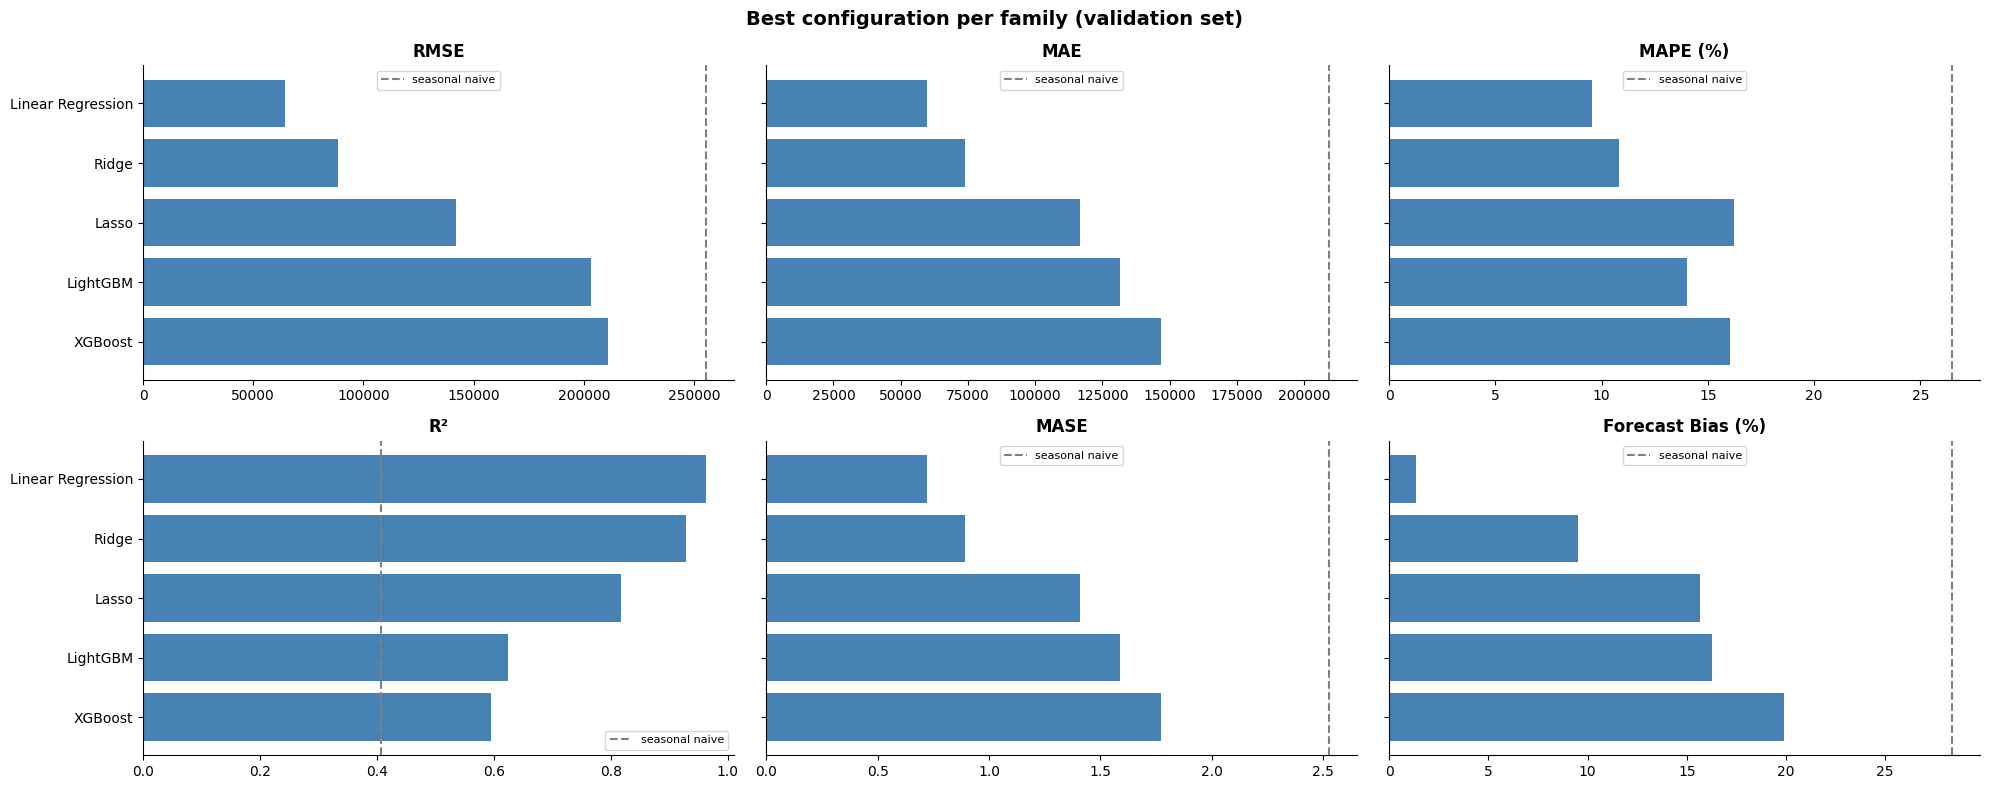

,family,transform,window,covid_rows,strategy,feature_set,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
0,linear,none,last_6y,keep,direct_single,lags+rolling+domain+cal_fourier+elapsed,64292.570,59769.485,9.543,0.962,0.722,1.341
1,ridge,none,last_6y,keep,direct_single,lags+growth+rolling+domain+cal_fourier,88673.378,73725.662,10.820,0.928,0.890,9.534
2,lasso,log,last_14y,keep,recursive,lags+rolling+domain+cal_fourier+elapsed,141944.405,116552.747,16.206,0.817,1.407,15.653
3,lightgbm,auto_stationary,all,keep,direct_single,lags+rolling+domain,203058.371,131592.617,14.033,0.625,1.589,16.265
4,xgboost,auto_stationary,last_10y,remove,direct_single,lags+growth+domain+cal_fourier,211181.604,146591.465,16.019,0.594,1.770,19.878


In [15]:
best_per_family = ranked.groupby('family', sort=False).first()
best_per_family = best_per_family.reindex([
    f for f in FAMILIES if f in best_per_family.index
]).reset_index()
best_per_family['label'] = best_per_family['family'].map(FAMILY_NAMES)

METRIC_LABELS = {
    'RMSE': 'RMSE',
    'MAE': 'MAE',
    'MAPE': 'MAPE (%)',
    'R2': 'R²',
    'MASE': 'MASE',
    'Forecast Bias': 'Forecast Bias (%)',
}

fig, axes = plt.subplots(2, 3, figsize=(20, 8), sharey=True)
fig.suptitle(
    'Best configuration per family (validation set)', fontsize=14, fontweight='bold'
)
for ax, col in zip(axes.flat, METRICS):
    title = METRIC_LABELS[col]
    ax.barh(
        best_per_family['label'][::-1], best_per_family[col][::-1], color='steelblue'
    )
    ax.axvline(
        float(baselines.loc['seasonal_naive', col]),
        color='grey',
        linestyle='--',
        label='seasonal naive',
    )
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

best_per_family[[*PARAM_KEYS, *METRICS]].round(3)

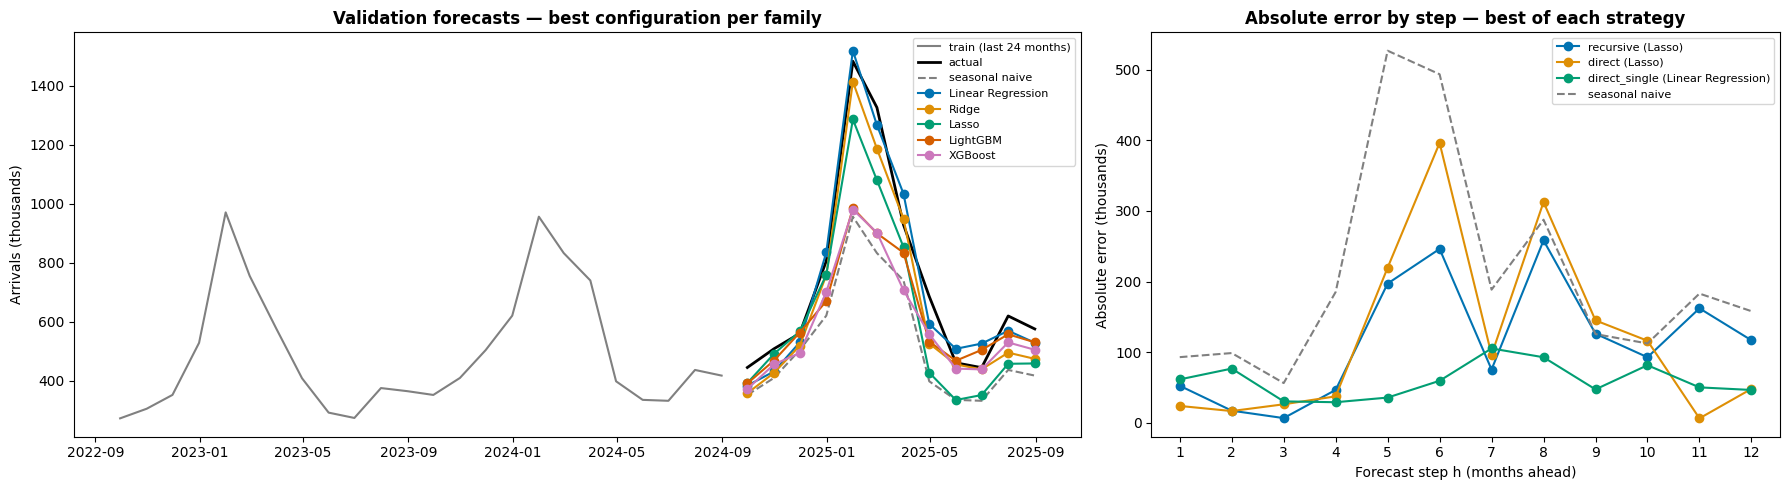

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={'width_ratios': [1.6, 1]})
context = train_series.iloc[-24:]
axes[0].plot(context.index, context / 1e3, color='grey', label='train (last 24 months)')
axes[0].plot(
    val_series.index, val_series / 1e3, color='black', linewidth=2, label='actual'
)
axes[0].plot(
    val_series.index,
    baseline_forecasts['seasonal_naive'] / 1e3,
    color='grey',
    linestyle='--',
    label='seasonal naive',
)
for _, row in best_per_family.iterrows():
    axes[0].plot(
        val_series.index, row['prediction'] / 1e3, marker='o', label=row['label']
    )
axes[0].set_title(
    'Validation forecasts — best configuration per family', fontweight='bold'
)
axes[0].set_ylabel('Arrivals (thousands)')
axes[0].legend(fontsize=8)

steps = np.arange(1, HORIZON + 1)
for strategy in STRATEGIES:
    best = ranked[ranked['strategy'] == strategy].iloc[0]
    axes[1].plot(
        steps,
        best['abs_errors'] / 1e3,
        marker='o',
        label=f'{strategy} ({FAMILY_NAMES[best["family"]]})',
    )
axes[1].plot(
    steps,
    np.abs(val_series - baseline_forecasts['seasonal_naive']).to_numpy() / 1e3,
    color='grey',
    linestyle='--',
    label='seasonal naive',
)
axes[1].set_title('Absolute error by step — best of each strategy', fontweight='bold')
axes[1].set_xlabel('Forecast step h (months ahead)')
axes[1].set_ylabel('Absolute error (thousands)')
axes[1].set_xticks(steps)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Top 10 Configurations — Validation Forecasts

The same view as notebook 5's *Final Result*: the ten best configurations of the grid (by
validation RMSE), each with the last 24 training months, the actual validation year and the
forecast. The training line is coloured by model family.

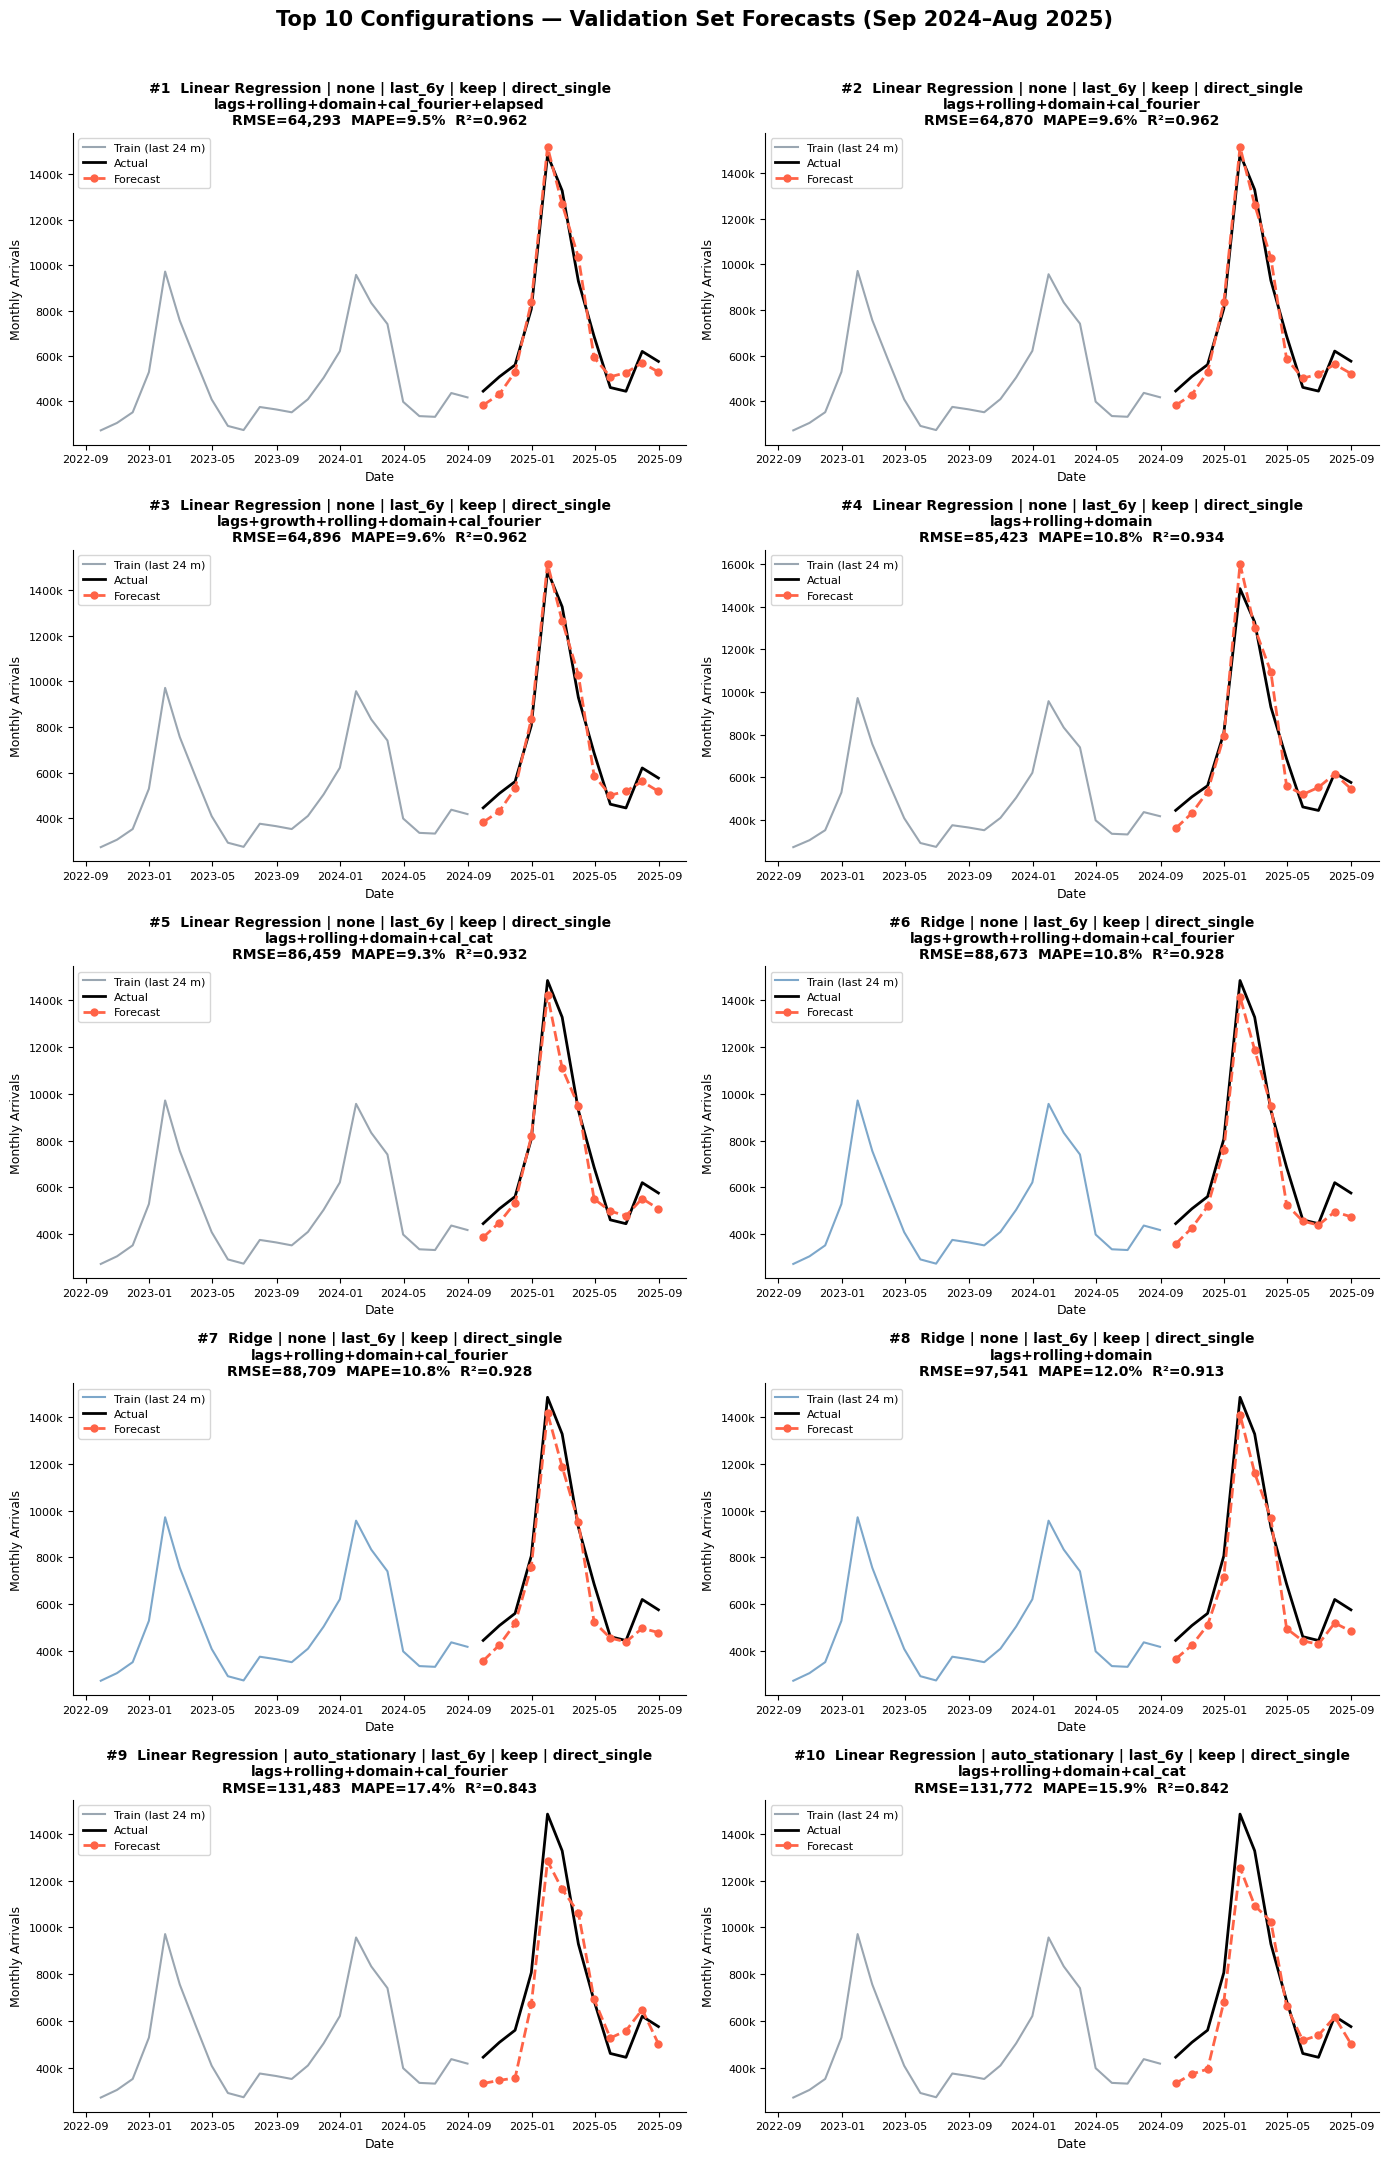

In [17]:
FAMILY_COLORS = {
    'linear': 'slategray',
    'ridge': 'steelblue',
    'lasso': 'mediumpurple',
    'lightgbm': 'seagreen',
    'xgboost': 'darkorange',
}
TOP_N_FORECASTS = 10

top10 = ranked.head(TOP_N_FORECASTS)
train_plot = train_series.iloc[-24:]

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
fig.suptitle(
    f'Top 10 Configurations — Validation Set Forecasts '
    f'({val_series.index[0]:%b %Y}–{val_series.index[-1]:%b %Y})',
    fontsize=15,
    fontweight='bold',
)

for i, (ax, (_, row)) in enumerate(zip(axes.flat, top10.iterrows())):
    ax.plot(
        train_plot.index,
        train_plot.values,
        label='Train (last 24 m)',
        linewidth=1.5,
        color=FAMILY_COLORS[row['family']],
        alpha=0.7,
    )
    ax.plot(
        val_series.index,
        val_series.values,
        label='Actual',
        linewidth=2,
        color='black',
    )
    ax.plot(
        val_series.index,
        row['prediction'],
        label='Forecast',
        linewidth=2,
        linestyle='--',
        color='tomato',
        marker='o',
        markersize=5,
    )

    ax.set_title(
        f'#{i + 1}  {FAMILY_NAMES[row["family"]]} | {row["transform"]} | '
        f'{row["window"]} | {row["covid_rows"]} | {row["strategy"]}\n'
        f'{row["feature_set"]}\n'
        f'RMSE={row["RMSE"]:,.0f}  MAPE={row["MAPE"]:.1f}%  R²={row["R2"]:.3f}',
        fontsize=10,
        fontweight='bold',
    )
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Monthly Arrivals', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1000)}k'))
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

for ax in axes.flat[len(top10) :]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 9. Heatmaps of the Combinations

As in notebook 5, each cell is the **best validation RMSE** among all configurations that share the
two choices on its axes (the best over every other choice). Reading the maps side by side
shows which choices matter most and which pairs work well together.

- Green is better. The colour scale stops at 1.5 × the seasonal naive RMSE, so a few exploding
  configurations do not wash out the differences between the good ones.
- Cells are in thousands of arrivals; `>1M` marks configurations whose best error is above one
  million.

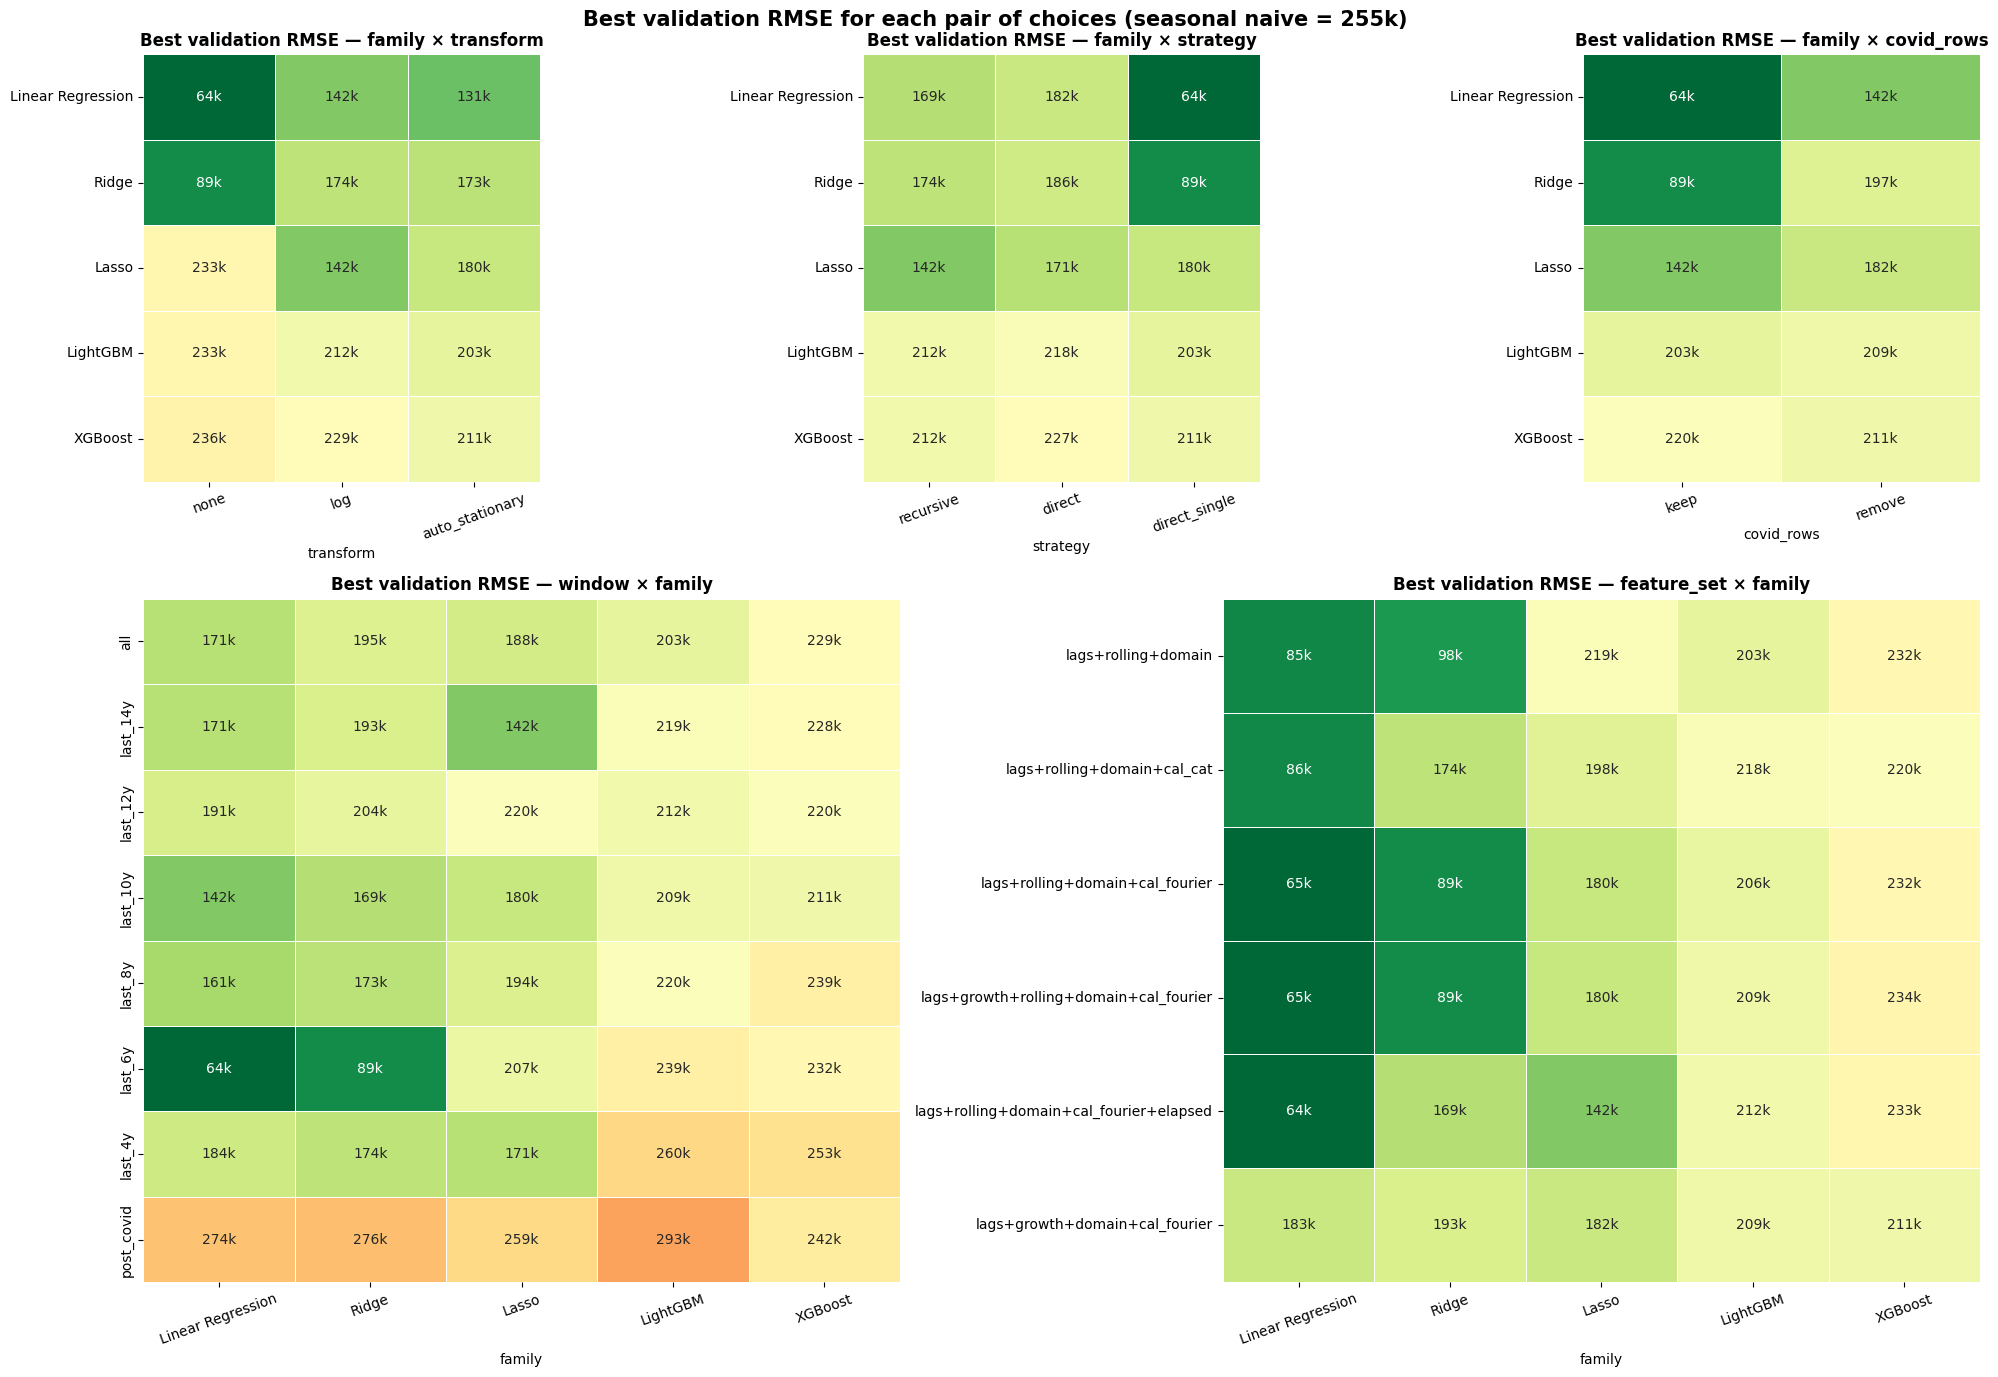

In [18]:
ORDERS = {
    'family': FAMILIES,
    'transform': TARGET_TRANSFORMS,
    'window': list(WINDOWS),
    'covid_rows': COVID_ROWS,
    'strategy': STRATEGIES,
    'feature_set': [set_label(s) for s in FEATURE_SETS],
}
HEATMAP_LAYOUT = [
    # (rows, columns, grid position)
    ('family', 'transform', (0, slice(0, 2))),
    ('family', 'strategy', (0, slice(2, 4))),
    ('family', 'covid_rows', (0, slice(4, 6))),
    ('window', 'family', (1, slice(0, 3))),
    ('feature_set', 'family', (1, slice(3, 6))),
]
RMSE_LABEL_CAP = 1e6


def rmse_labels(pivot):
    return pivot.map(
        lambda v: (
            '' if pd.isna(v) else ('>1M' if v > RMSE_LABEL_CAP else f'{v / 1e3:,.0f}k')
        )
    )


def best_rmse_pivot(rows, columns):
    pivot = ranked.pivot_table(
        index=rows, columns=columns, values='RMSE', aggfunc='min'
    )
    pivot = pivot.reindex(
        index=[v for v in ORDERS[rows] if v in pivot.index],
        columns=[v for v in ORDERS[columns] if v in pivot.columns],
    )
    if rows == 'family':
        pivot = pivot.rename(index=FAMILY_NAMES)
    if columns == 'family':
        pivot = pivot.rename(columns=FAMILY_NAMES)
    return pivot


fig = plt.figure(figsize=(20, 14))
grid = fig.add_gridspec(2, 6, height_ratios=[1, 1.6])
for rows, columns, (r, c) in HEATMAP_LAYOUT:
    ax = fig.add_subplot(grid[r, c])
    pivot = best_rmse_pivot(rows, columns)
    sns.heatmap(
        pivot,
        annot=rmse_labels(pivot),
        fmt='',
        cmap='RdYlGn_r',
        vmin=ranked['RMSE'].min(),
        vmax=BASELINE_RMSE * 1.5,
        linewidths=0.4,
        cbar=False,
        ax=ax,
    )
    ax.set_title(f'Best validation RMSE — {rows} × {columns}', fontweight='bold')
    ax.set_xlabel(columns)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelrotation=20)
fig.suptitle(
    'Best validation RMSE for each pair of choices '
    f'(seasonal naive = {BASELINE_RMSE / 1e3:,.0f}k)',
    fontsize=15,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

## 10. Feature Importance of the Best Configuration per Family

The best configuration of each family is refitted to inspect what it relies on.

- **Native importance** (`MLForecast.feature_importance()`): coefficients for the linear
  models (comparable because `normalize=True`; Lasso's zeros are the features it dropped) and
  the built-in importance of the tree models. For the direct strategy the model of step 1 is
  shown.
- **Permutation importance by group** on the validation set (the book's most reliable measure). All
  columns of a group are shuffled together (for example the `sin` and `cos` of one frequency),
  the model predicts again and the MAE increase is measured. The features are built from the
  actual validation history (teacher forcing), so every model is scored on the rows it would see at
  its own shift; the direct strategy averages its 12 models. `MLForecast` is not a full
  scikit-learn estimator, so the permutation is done by hand.

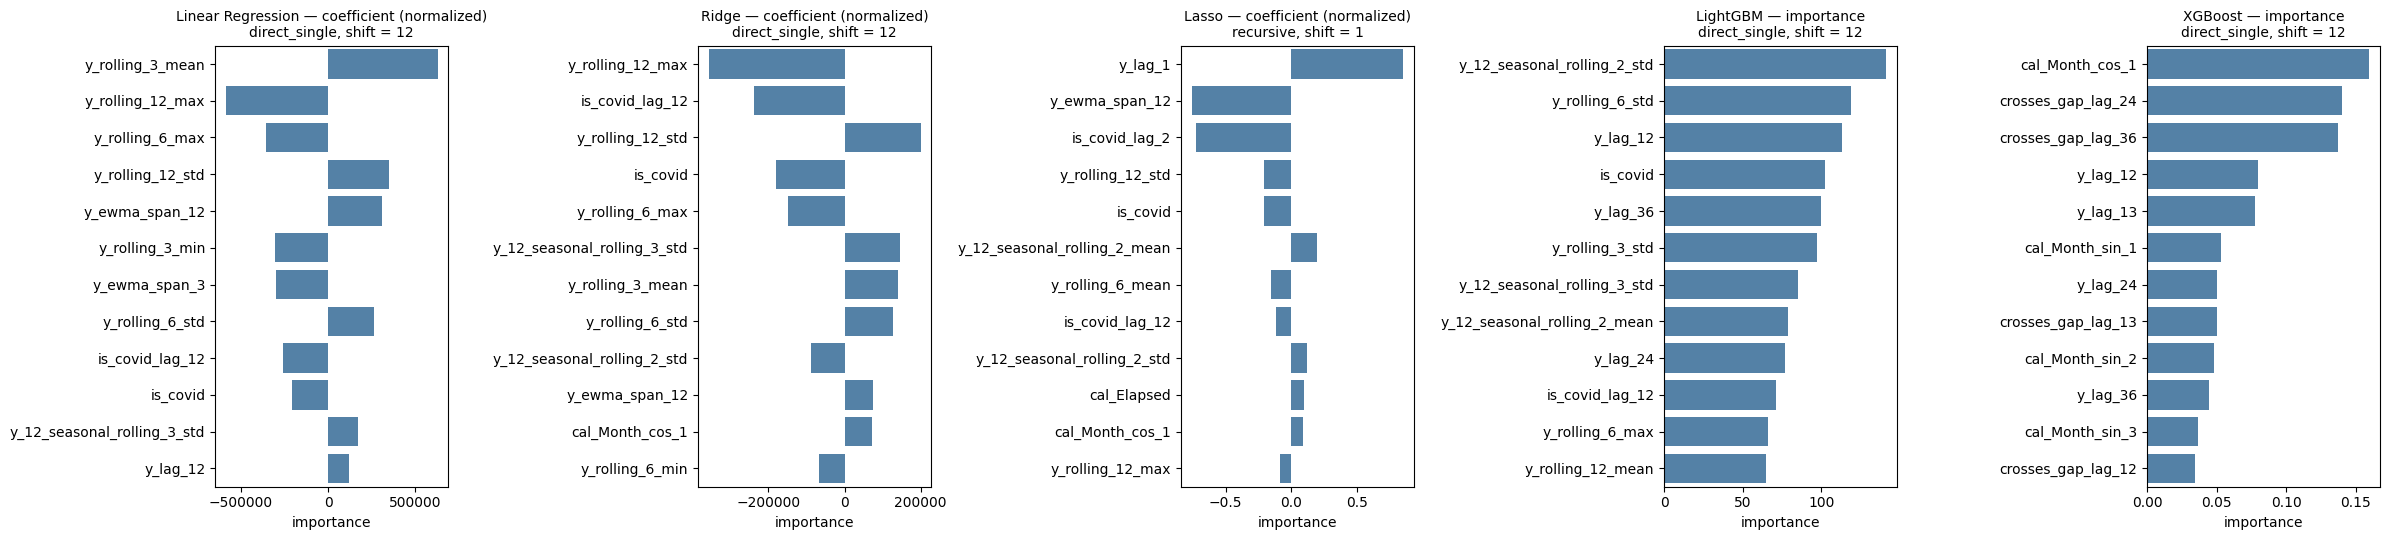

In [19]:
def refit(row):
    config = Config(
        row['family'],
        row['transform'],
        row['window'],
        row['covid_rows'],
        row['strategy'],
        canonical(row['feature_set'].split('+')),
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _, models = forecast_arrivals(
            config, setups[config.transform, config.covid_rows]
        )
    return config, models


best_models = {row['family']: refit(row) for _, row in best_per_family.iterrows()}

TOP_FEATURES = 12
fig, axes = plt.subplots(1, len(best_models), figsize=(24, 5.5))
for ax, family in zip(axes, best_models):
    config, models = best_models[family]
    shift, (model, _) = next(iter(models.items()))
    importance = model.feature_importance().head(TOP_FEATURES)
    sns.barplot(data=importance, x='importance', y='feature', ax=ax, color='steelblue')
    kind = 'importance' if family in TREE_FAMILIES else 'coefficient (normalized)'
    ax.set_title(
        f'{FAMILY_NAMES[family]} — {kind}\n{config.strategy}, shift = {shift}',
        fontsize=10,
    )
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

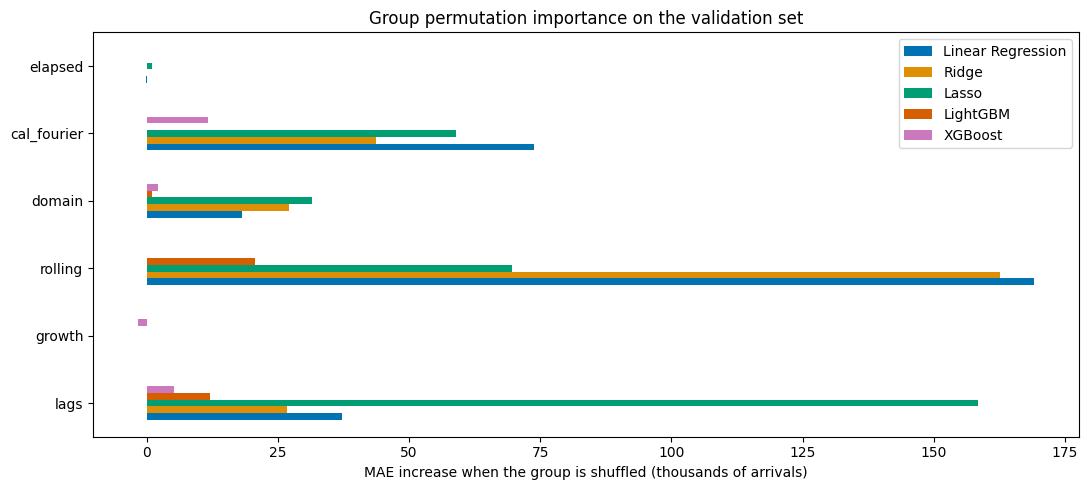

,Linear Regression,Ridge,Lasso,LightGBM,XGBoost
lags,37302.0,26800.0,158506.0,12086.0,5197.0
growth,NaN,155.0,NaN,NaN,-1686.0
rolling,169149.0,162544.0,69666.0,20729.0,NaN
domain,18171.0,27197.0,31602.0,964.0,2186.0
cal_fourier,73903.0,43752.0,58888.0,NaN,11669.0
elapsed,-86.0,NaN,1113.0,NaN,NaN


In [20]:
N_REPEATS = 30


def group_permutation_importance(config, models, n_repeats=N_REPEATS):
    """Validation MAE increase when the columns of a group are shuffled together."""
    setup = setups[config.transform, config.covid_rows]
    observed = pd.concat([setup['train_part'], val_series])
    full = make_history(setup['transformer'].transform(observed), observed)
    rng = np.random.default_rng(RANDOM_STATE)
    increases = {group: [] for group in config.feature_set}
    for shift, (model, feature_config) in models.items():
        features, groups = build_features(full, shift)
        rows = features[features['date'].isin(val_series.index)].reset_index(drop=True)

        def mae_of(frame):
            predicted_z = predict_rows(model, feature_config, frame, config.feature_set)
            predicted = to_arrivals(
                setup, pd.Series(predicted_z.to_numpy(), index=val_series.index)
            )
            return float(np.mean(np.abs(val_series.to_numpy() - predicted.to_numpy())))

        base = mae_of(rows)
        for group in config.feature_set:
            scores = []
            for _ in range(n_repeats):
                shuffled = rows.copy()
                order = rng.permutation(len(rows))
                shuffled[groups[group]] = (
                    rows[groups[group]].iloc[order].set_axis(rows.index)
                )
                scores.append(mae_of(shuffled) - base)
            increases[group].append(np.mean(scores))
    return pd.Series({group: np.mean(values) for group, values in increases.items()})


with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    permutation = (
        pd
        .DataFrame({
            FAMILY_NAMES[family]: group_permutation_importance(*best_models[family])
            for family in best_models
        })
        .reindex(GROUP_ORDER)
        .dropna(how='all')
    )

ax = (permutation / 1e3).plot.barh(figsize=(11, 5))
ax.set_title('Group permutation importance on the validation set')
ax.set_xlabel('MAE increase when the group is shuffled (thousands of arrivals)')
plt.tight_layout()
plt.show()
permutation.round(0)

## Reading the Results

| Question | Where |
|---|---|
| Does any ML model beat the seasonal naive? | `beats_seasonal_naive` in section 8, the dashed lines of the bar charts |
| Which family and target processing work best? | Heatmap *family × transform* |
| Which multi-step strategy suits each family? | Heatmap *family × strategy* and the error-by-step curves |
| Does removing the pandemic years help? | Heatmap *family × covid_rows* |
| How much history should a model see? | Heatmap *window × family* |
| Which feature groups matter? | Heatmap *feature_set × family* and the group permutation importance |
| How does ML compare with SARIMAX? | Section 8 metrics against notebook 5 (same validation year, metrics and baselines) |

Things to keep in mind:

- **Selection on the validation set.** As in notebook 5, the best of thousands of
  configurations on 12 validation months is optimistic. Compare families and choices through
  the heatmaps rather than through a single top score; the unbiased score comes from the test
  year in the final notebook.
- **Trees and levels.** If the tree models only do well with `log` or `auto_stationary`, that
  is their extrapolation limit: on the raw scale they cannot forecast above the training
  maximum.
- **Log target and unregularized models.** On the log scale the COVID months (a few hundred
  arrivals against hundreds of thousands) are extreme outliers. A linear model without a
  penalty can extrapolate badly from them, and `exp()` turns a moderate error on the log scale
  into a forecast many times too large. Very large errors for `Linear Regression | log` are
  this effect, not a bug. Removing the COVID years is expected to help here most.